# 0. Environment Setup and Installations

In [ ]:
# 0. Environment Setup and Installations

# 1. Mount Google Drive to access your files
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)

# 2. Extract the balanced dataset directly to the working directory
print("Unzipping Balanced Dataset... this might take a few minutes.")
!rm -rf /content/dataset
os.makedirs("/content/dataset", exist_ok=True)
zip_path = "/content/drive/MyDrive/Deepfake_Project/CelebA_HQ_Balanced_ZeroShot.zip"
!unzip -q "{zip_path}" -d "/content/dataset"
print("Unzip complete!")

# 3. Install necessary libraries
print("Installing required libraries...")
!pip install -q transformers accelerate bitsandbytes torch torchvision Pillow tqdm pandas scikit-learn matplotlib seaborn
print("Installations complete! Ready for Data Extraction.")

Mounted at /content/drive
Unzipping Balanced Dataset... this might take a few minutes.
Unzip complete!
Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.3 MB/s eta 0:00:00
Installations complete! Ready for Data Extraction.


# 1 Copy Img from Drive

In [ ]:
# 0.5 Define Paths & Data Sanity Check
import os
import glob

# define the paths
real_dir = '/content/dataset/real'
fake_dir = '/content/dataset/fake'

# scan all the images
real_images = glob.glob(f"{real_dir}/*.*")
fake_images = glob.glob(f"{fake_dir}/*.*")

print(" Data Loading Summary:")
print(f"Found {len(real_images)} REAL images.")
print(f"Found {len(fake_images)} FAKE images.")

if len(real_images) == 0 or len(fake_images) == 0:
    print(" ERROR: Missing images! Check your extraction process in Cell 0.")
else:
    print(f" Total: {len(real_images) + len(fake_images)} images accurately loaded and mapped.")

🔍 Data Loading Summary:
📊 Found 17643 REAL images.
📊 Found 17643 FAKE images.
✅ Total: 35286 images accurately loaded and mapped.


#2. Model Initialization

In [ ]:
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print(" Loading Processor...")
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-7b")

print(" Loading Base Model in bfloat16 for Maximum Efficiency...")
model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.bfloat16
).to(device)

# --- ZERO-SHOT OPTIMIZATION ---
# at zero-shot Freeze all the model weights to save Vram
for param in model.parameters():
    param.requires_grad = False

model.eval() # Enter the model to evaluation mode

print("Model loaded successfully and fully frozen for pure Zero-Shot inference!")

🧠 Loading Processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/104k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

✅ Model loaded successfully and fully frozen for pure Zero-Shot inference!


# 3. Dataset Loading

In [ ]:
import os
import glob
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import multiprocessing

class PreExtractedDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row['image_path']
        label_str = row['label'] # Expected: "Yes" or "No"

        # Load image and set prompt
        image = Image.open(image_path).convert('RGB')
        prompt = "is this photo real?"

        # 1. Process ONLY the base prompt and image
        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        # 2. Pass the plain text label directly to the batch dictionary for evaluation
        inputs['text_label'] = label_str
        return inputs

fake_images_folder = '/content/dataset/fake'
real_images_folder = '/content/dataset/real'

all_paths = []
all_labels = []

# Collect Fake images
if os.path.exists(fake_images_folder):
    fake_paths = glob.glob(os.path.join(fake_images_folder, '*.*'))
    all_paths.extend(fake_paths)
    all_labels.extend(["No"] * len(fake_paths))
else:
    print(f"Warning: Fake folder not found at {fake_images_folder}")

# Collect Real images
if os.path.exists(real_images_folder):
    real_paths = glob.glob(os.path.join(real_images_folder, '*.*'))
    all_paths.extend(real_paths)
    all_labels.extend(["Yes"] * len(real_paths))
else:
    print(f"Warning: Real folder not found at {real_images_folder}")

print(f"Total images found: {len(all_paths)}")

if len(all_paths) > 0:
    # 1. Create a Pandas DataFrame
    test_df = pd.DataFrame({'image_path': all_paths, 'label': all_labels})
    print(f"Testing images (Zero-Shot): {len(test_df)}")

    # 2. Create Dataset
    test_dataset = PreExtractedDeepfakeDataset(test_df, processor)

    # Calculate automatically the amount of free threads
    optimal_workers = min(8, multiprocessing.cpu_count())

    # 3. Create DataLoader optimized for A100
    test_dataloader = DataLoader(
        test_dataset,
        batch_size=32,  # Increased for A100 speed
        shuffle=False,
        num_workers=optimal_workers,
        pin_memory=True,
        prefetch_factor=2
    )
    print(" test_dataloader created successfully for Pure Zero-Shot!")
else:
    print(" ERROR: No images loaded. Please check your folder paths.")

Total images found: 35286
Testing images (Zero-Shot): 35286
✅ test_dataloader created successfully for Pure Zero-Shot!


# 5. Model Evaluation and Metrics

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm

model.eval()

all_fake_probabilities = []
all_true_numerical_labels = []

# 1. Define multiple valid tokens for each class to handle capitalization variations
yes_tokens = ["Yes", "yes", " Yes", " yes"]
no_tokens = ["No", "no", " No", " no"]

# 2. Get the token IDs for all variations
yes_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in yes_tokens]
no_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in no_tokens]

print(" Starting  Zero-Shot Inference ")

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating Test Set"):

        pixel_values = batch['pixel_values'].to(device, dtype=torch.bfloat16)
        qformer_input_ids = batch['qformer_input_ids'].to(device)
        qformer_attention_mask = batch['qformer_attention_mask'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Build numerical true labels dynamically from the raw text labels
        # "No" means Fake (1), "Yes" means Real (0)
        text_labels = batch['text_label']
        numerical_labels = torch.tensor([1 if "no" in label.lower() else 0 for label in text_labels])

        # Generate the first token to extract its scores (Pure Zero-Shot)
        outputs = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

        first_token_logits = outputs.scores[0]

        # 3. Convert ALL logits to probabilities
        full_vocab_probs = F.softmax(first_token_logits, dim=-1)

        # 4. Extract and SUM the specific probabilities
        yes_prob = sum(full_vocab_probs[:, tid] for tid in yes_token_ids)
        no_prob = sum(full_vocab_probs[:, tid] for tid in no_token_ids)

        # 5. Apply Normalization: P_no / (P_yes + P_no)
        epsilon = 1e-8
        fake_probability = no_prob / (yes_prob + no_prob + epsilon)

        all_fake_probabilities.extend(fake_probability.cpu().tolist())
        all_true_numerical_labels.extend(numerical_labels.tolist())

# Calculate Final AUC Score
auc_score = roc_auc_score(all_true_numerical_labels, all_fake_probabilities)
print(f"\n Final Test ROC-AUC Score: {auc_score:.4f}")

# Calculate Accuracy with Optimal Threshold
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
best_acc = 0.0
best_thresh = 0.0

for thresh in thresholds:
    binary_preds = [1 if prob >= thresh else 0 for prob in all_fake_probabilities]
    acc = accuracy_score(all_true_numerical_labels, binary_preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f" Optimal Threshold: {best_thresh}")
print(f" Test Accuracy (ACC): {best_acc * 100:.2f}%")

 Starting  Zero-Shot Inference 


Evaluating Test Set: 100%|██████████| 1103/1103 [04:08<00:00,  4.44it/s]



 Final Test ROC-AUC Score: 0.7432
 Optimal Threshold: 0.3
 Test Accuracy (ACC): 73.40%


#6.Graphs

Generating and saving graphs for CelebA-HQ Zero-Shot...


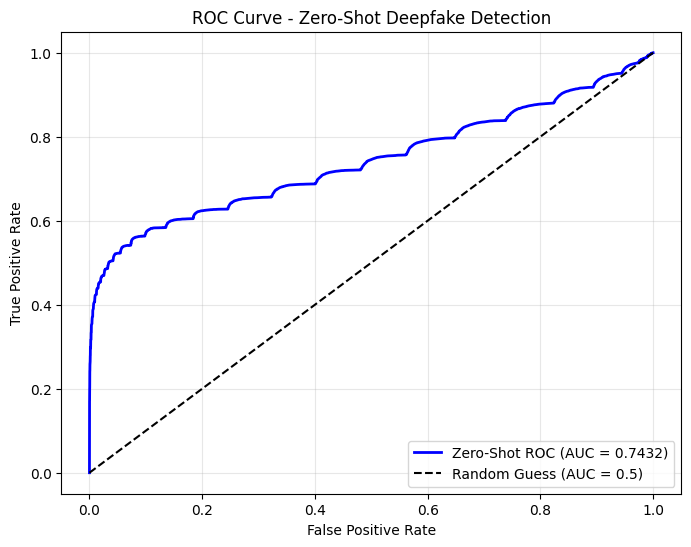

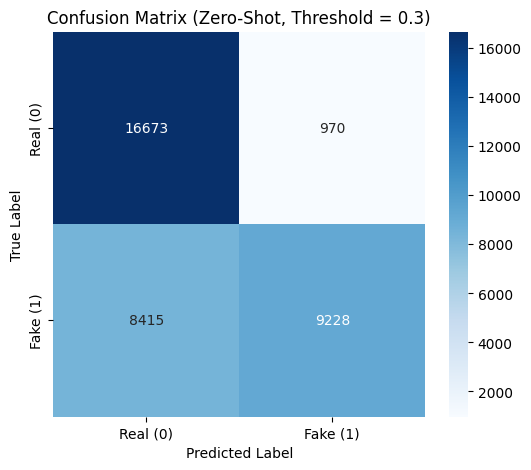

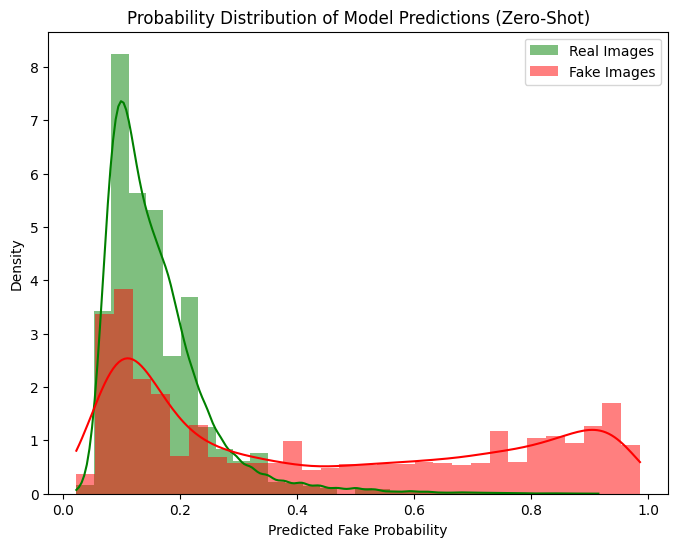

No embeddings found. Skipping t-SNE graph.
✅ Success! All graphs have been saved to your Drive at: /content/drive/MyDrive/Deepfake_Project/Graphs_CelebA_ZeroShot


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix
from sklearn.manifold import TSNE
import numpy as np
import os
from sklearn.metrics import silhouette_score

# 1. Create a folder in your Drive to save the CelebA-HQ graphs safely
graph_dir = "/content/drive/MyDrive/Deepfake_Project/Graphs_CelebA_ZeroShot"
os.makedirs(graph_dir, exist_ok=True)

print("Generating and saving graphs for CelebA-HQ Zero-Shot...")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(all_true_numerical_labels, all_fake_probabilities)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Zero-Shot ROC (AUC = {auc_score:.4f})', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Zero-Shot Deepfake Detection')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve_zeroshot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3. Confusion Matrix
optimal_thresh = best_thresh
binary_preds = [1 if prob >= optimal_thresh else 0 for prob in all_fake_probabilities]
cm = confusion_matrix(all_true_numerical_labels, binary_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Zero-Shot, Threshold = {optimal_thresh})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix_zeroshot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 4. Probability Distribution Plot
plt.figure(figsize=(8, 6))
real_probs = [prob for prob, label in zip(all_fake_probabilities, all_true_numerical_labels) if label == 0]
fake_probs = [prob for prob, label in zip(all_fake_probabilities, all_true_numerical_labels) if label == 1]

sns.histplot(real_probs, color='green', label='Real Images', kde=True, stat="density", linewidth=0, alpha=0.5, bins=30)
sns.histplot(fake_probs, color='red', label='Fake Images', kde=True, stat="density", linewidth=0, alpha=0.5, bins=30)

plt.xlabel('Predicted Fake Probability')
plt.ylabel('Density')
plt.title('Probability Distribution of Model Predictions (Zero-Shot)')
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist_zeroshot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 5. Training Loss Convergence Graph (Will safely skip since there is no training)
if 'training_loss_history' in locals() and len(training_loss_history) > 0:
    plt.figure(figsize=(8, 6))
    plt.plot(training_loss_history, label='Training Loss', color='purple', linewidth=2)
    plt.xlabel('Batch / Iteration')
    plt.ylabel('Loss')
    plt.title('Training Loss Convergence (Zero-Shot)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(graph_dir, 'training_loss_zeroshot.png'), dpi=300, bbox_inches='tight')
    plt.show()

#  6. t-SNE Clustering & Silhouette Analysis ---
if 'all_embeddings' in locals() and len(all_embeddings) > 0:
    print("Calculating metrics and performing t-SNE (this may take a minute)...")

    # Convert lists to numpy arrays
    embeddings_np = np.array(all_embeddings)
    labels_np = np.array(all_true_numerical_labels)

    # --- Calculate Mathematical Cohesion & Separation ---
    sil_score = silhouette_score(embeddings_np, labels_np)
    print(f"\nMathematical Separation Proof:")
    print(f"Silhouette Score: {sil_score:.4f} (Closer to 1 means better separation)\n")

    # Initialize and fit t-SNE (reducing to 2 dimensions for plotting)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings_np)

    # Plot the clusters
    plt.figure(figsize=(10, 8))

    # Scatter plot: color mapped to Real (0) / Fake (1)
    sns.scatterplot(
        x=embeddings_2d[:, 0],
        y=embeddings_2d[:, 1],
        hue=labels_np,
        palette={0: 'green', 1: 'red'},
        alpha=0.7,
        s=50 # Point size
    )

    # Update legend to clearly show correct mappings
    handles, _ = plt.gca().get_legend_handles_labels()
    plt.legend(handles, ['Real (Yes)', 'Fake (No)'], title='Ground Truth')

    # Added the Silhouette score directly into the graph title!
    plt.title(f't-SNE Clustering of Q-Former Embeddings\nSilhouette Score: {sil_score:.4f}')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True, alpha=0.3)

    plt.savefig(os.path.join(graph_dir, 'tsne_clustering_zeroshot.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No embeddings found. Skipping t-SNE graph.")

print(f"✅ Success! All graphs have been saved to your Drive at: {graph_dir}")